In [14]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm

from JAX_BSSN.evolve import rk4_step
from JAX_BSSN.bssn import BSSNVariables, BSSNParameters, compute_momentum_constraint
from JAX_BSSN.errors import compute_hamiltonian_constraint
from JAX_BSSN.derivatives import diff1_field
from JAX_BSSN.tensor_algebra import (
    invert_3x3_metric,
    christoffel_symbols_second_kind,
    trace_tensor,
    traceless_part,
)


This is a demonstration of a gauge wave simulation using the JAX_BSSN code.

This simulation uses harmonic gauge slicing and zero-shift conditions to evolve a 1D gauge wave.

$$
ds^{2} = -H\,dt^{2} + H\,dx^{2} + dy^{2} + dz^{2},
$$

where

$$
H = 1 - A \sin\!\left(\frac{2\pi (x - t)}{d}\right).
$$

The nonzero component of the extrinsic curvature is
$$
K_{xx} = -\frac{\pi A}{d}\,
\frac{\cos\!\left(\frac{2\pi (x - t)}{d}\right)}{\sqrt{1 - A \sin\!\left(\frac{2\pi (x - t)}{d}\right)}},
$$
and
$$
K_{ij} = 0 \quad \text{otherwise.}
$$


I will be using the Bona-Masso slicing condition: $$\partial_{t}\alpha = -\alpha^{2} \gamma^{ij} K_{ij}$$

Resolution Parameters:

- Number of grid points (nx): 50
- Domain length (L): 1.0, x ∈ [-0.5, 0.5]
- Time step (dt): 0.25 * dx

- Amplitude (A): 0.1
- Wavelength (d): 1.0

In [15]:
def make_cell_centered_grid(nx, L=1.0):
    dx = L / nx
    x = -L / 2 + (jnp.arange(nx) + 0.5) * dx
    return x, dx


def l2_norm_over_x(history, dx):
    return jnp.sqrt(dx * jnp.sum(history**2, axis=1))


def restrict_history_cell_centered(history, refinement_ratio):
    """
    Restrict cell-centered data by repeated pair-averaging.
    For ratio=2, coarse cell centers lie midway between fine centers.
    """
    out = history
    ratio = int(refinement_ratio)
    while ratio > 1:
        out = 0.5 * (out[:, 0::2] + out[:, 1::2])
        ratio //= 2
    return out


def run_gauge_wave(x, dt, dx, Nt, snapshot_stride, A, d, show_progress=True):
    def H(x_, t_):
        return 1.0 - A * jnp.sin((2.0 * jnp.pi * (x_ - t_)) / d)

    nx = x.shape[0]

    alpha = jnp.expand_dims(jnp.sqrt(H(x, 0.0)), axis=(1, 2))
    beta = jnp.zeros((3, nx, 1, 1))

    conformal_factor = jnp.power(H(x, 0.0), -1 / 6)

    gamma = jnp.zeros((3, 3, nx, 1, 1))
    gamma = gamma.at[0, 0, :, 0, 0].set(H(x, 0.0) * conformal_factor**2)
    gamma = gamma.at[1, 1, :, 0, 0].set(conformal_factor**2)
    gamma = gamma.at[2, 2, :, 0, 0].set(conformal_factor**2)

    K = jnp.zeros_like(gamma)
    K_xx = - (jnp.pi * A / d) * jnp.cos((2.0 * jnp.pi * x) / d) / jnp.sqrt(H(x, 0.0))
    K = K.at[0, 0, :, 0, 0].set(K_xx)

    inv_gamma = invert_3x3_metric(gamma)
    A_ij = conformal_factor**2 * traceless_part(K, gamma, inv_gamma)
    K_trace = trace_tensor(K, inv_gamma)

    derivs = jnp.stack([diff1_field(gamma, d_ + 2, dx) for d_ in range(3)], axis=0)
    christoffel_2 = christoffel_symbols_second_kind(inv_gamma, derivs)
    initial_conformal_connection = jnp.einsum('mn..., imn... -> i...', inv_gamma, christoffel_2)

    conformal_factor = jnp.expand_dims(conformal_factor, axis=(1, 2))

    vars = BSSNVariables(
        conformal_metric=gamma,
        conformal_factor=conformal_factor,
        traceless_K=A_ij,
        trace_K=K_trace,
        conformal_connection=initial_conformal_connection,
        lapse=alpha,
        shift=beta,
    )

    params = BSSNParameters(
        eta=0.0,
        kappa=0.0,
        nu=0.0,
        f=1.0,
        g=0.0,
        dx=dx,
        dt=dt,
    )

    times = [0.0]
    physical_metric = vars.conformal_metric / (vars.conformal_factor**2)
    gxx_snapshots = [physical_metric[0, 0, :, 0, 0]]
    alpha_now = vars.lapse[:, 0, 0]
    alpha_snapshots = [alpha_now]
    alpha_max = [jnp.max(alpha_now)]

    ham_hist = [compute_hamiltonian_constraint(vars, params)]
    mom_hist = [compute_momentum_constraint(vars, params)]

    iterator = range(1, Nt + 1)
    if show_progress:
        iterator = tqdm(iterator, leave=False)

    for step in iterator:
        vars = rk4_step(vars, params)
        if (step % snapshot_stride == 0) or (step == Nt):
            physical_metric = vars.conformal_metric / (vars.conformal_factor**2)
            alpha_now = vars.lapse[:, 0, 0]
            times.append(step * dt)
            gxx_snapshots.append(physical_metric[0, 0, :, 0, 0])
            alpha_snapshots.append(alpha_now)
            alpha_max.append(jnp.max(alpha_now))
            ham_hist.append(compute_hamiltonian_constraint(vars, params))
            mom_hist.append(compute_momentum_constraint(vars, params))

    return (
        jnp.asarray(times),
        jnp.asarray(gxx_snapshots),
        jnp.asarray(alpha_snapshots),
        jnp.asarray(alpha_max),
        jnp.asarray(ham_hist),
        jnp.asarray(mom_hist),
    )


In [16]:
# Gauge wave setup (CQG 21 (2004) 589 section 4.2)
rhos = [1, 2, 4]
nxs = [50 * rho for rho in rhos]
L = 1.0
A = 1.0e-1
d = 1.0

xs = []
dxs = []
dts = []
steps_per_crossing = []
for nx in nxs:
    x, dx = make_cell_centered_grid(nx, L=L)
    dt = 0.25 * dx
    xs.append(x)
    dxs.append(dx)
    dts.append(dt)
    steps_per_crossing.append(int(round(d / dt)))

# NOTE:
# Paper settings are T_crossings=1000 and save_every_crossings=10.
# Those are expensive with Python loops; start shorter for debugging.
T_crossings = 1.0
save_every_crossings = 0.01

Nts = [int(round(T_crossings * spc)) for spc in steps_per_crossing]
snapshot_strides = [max(1, int(round(save_every_crossings * spc))) for spc in steps_per_crossing]

print('nxs:', nxs)
print('dxs:', dxs)
print('dts:', dts)
print('Nt :', Nts)
print('snapshot strides:', snapshot_strides)


nxs: [50, 100, 200]
dxs: [0.02, 0.01, 0.005]
dts: [0.005, 0.0025, 0.00125]
Nt : [200, 400, 800]
snapshot strides: [2, 4, 8]


In [17]:
all_times = {}
all_gxx = {}
all_alpha = {}
all_alpha_max = {}
all_gxx_analytic = {}
all_alpha_analytic = {}
all_hamiltonian_constraints = {}
all_momentum_constraints = {}

for nx, x, dx, dt, Nt, stride in zip(nxs, xs, dxs, dts, Nts, snapshot_strides):
    times, gxx_hist, alpha_hist, alpha_max_hist, ham_hist, mom_hist = run_gauge_wave(
        x=x,
        dt=dt,
        dx=dx,
        Nt=Nt,
        snapshot_stride=stride,
        A=A,
        d=d,
        show_progress=True,
    )

    all_times[nx] = times
    all_gxx[nx] = gxx_hist
    all_alpha[nx] = alpha_hist
    all_alpha_max[nx] = alpha_max_hist
    all_hamiltonian_constraints[nx] = ham_hist
    all_momentum_constraints[nx] = mom_hist

    gxx_exact = jax.vmap(lambda t: 1.0 - A * jnp.sin((2.0 * jnp.pi * (x - t)) / d))(times)
    alpha_exact = jnp.sqrt(gxx_exact)
    all_gxx_analytic[nx] = gxx_exact
    all_alpha_analytic[nx] = alpha_exact

# Make sure snapshots are time-aligned across resolutions.
t_ref = all_times[nxs[0]]
for nx in nxs[1:]:
    if all_times[nx].shape != t_ref.shape:
        raise ValueError(f'Time history length mismatch for nx={nx}')
    max_dt = jnp.max(jnp.abs(all_times[nx] - t_ref))
    print(f'max |dt_align| for nx={nx}:', float(max_dt))


max |dt_align| for nx=100: 0.0
max |dt_align| for nx=200: 0.0


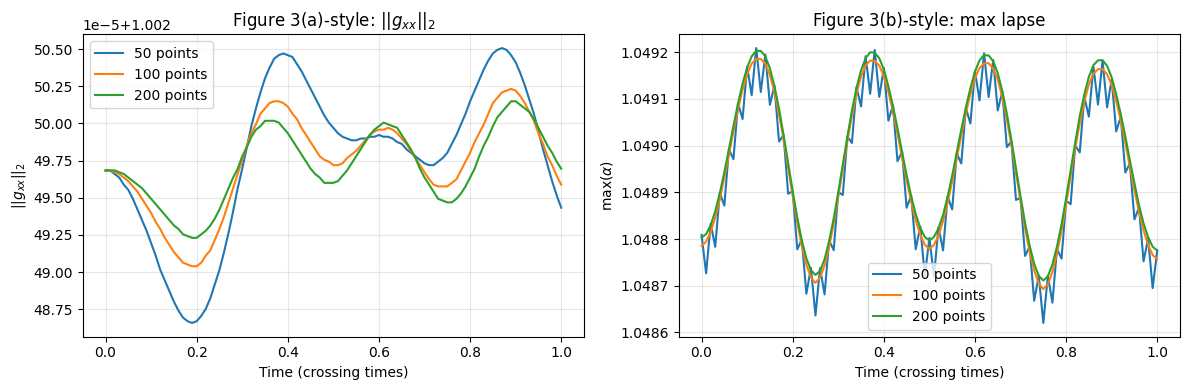

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for nx, dx in zip(nxs, dxs):
    times = all_times[nx]
    gxx_l2 = l2_norm_over_x(all_gxx[nx], dx)

    axes[0].plot(times, gxx_l2, label=f'{nx} points')
    axes[1].plot(times, all_alpha_max[nx], label=f'{nx} points')

axes[0].set_xlabel('Time (crossing times)')
axes[0].set_ylabel(r'$||g_{xx}||_{2}$')
axes[0].set_title('Figure 3(a)-style: $||g_{xx}||_2$')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('Time (crossing times)')
axes[1].set_ylabel(r'$\max(\alpha)$')
axes[1].set_title('Figure 3(b)-style: max lapse')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


gxx initial self-convergence order p = log2(CF): 1.908
alpha initial self-convergence order p = log2(CF): 1.999
Reference for exact 2nd order: CF = 4, p = 2


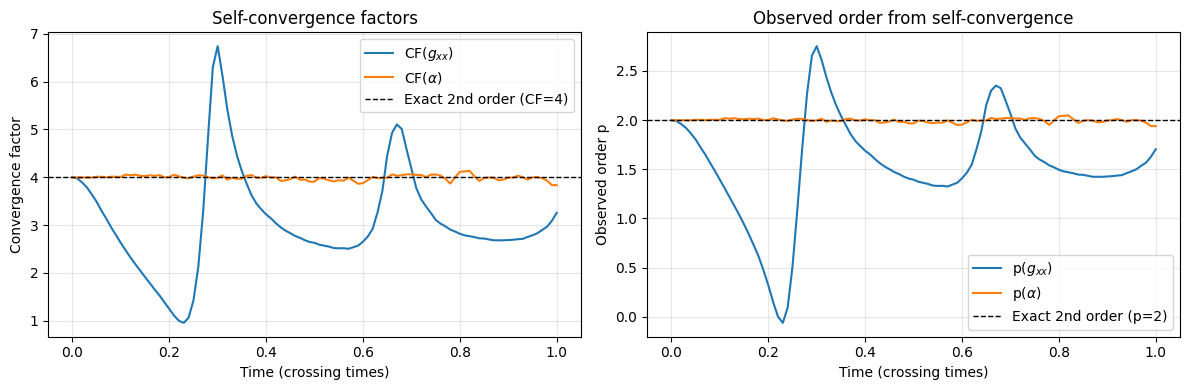

In [19]:
def self_convergence_factor(coarse_hist, mid_hist, fine_hist, dx_coarse, ratio_mid, ratio_fine):
    mid_on_coarse = restrict_history_cell_centered(mid_hist, ratio_mid)
    fine_on_coarse = restrict_history_cell_centered(fine_hist, ratio_fine)

    diff_c_m = l2_norm_over_x(coarse_hist - mid_on_coarse, dx_coarse)
    diff_m_f = l2_norm_over_x(mid_on_coarse - fine_on_coarse, dx_coarse)

    eps = 1e-16
    cf = diff_c_m / (diff_m_f + eps)
    p = jnp.log2(cf + eps)
    return cf, p


nx_coarse, nx_mid, nx_fine = nxs
ratio_mid = nx_mid // nx_coarse
ratio_fine = nx_fine // nx_coarse

times = all_times[nx_coarse]
dx_coarse = dxs[0]

cf_gxx, p_gxx = self_convergence_factor(
    all_gxx[nx_coarse],
    all_gxx[nx_mid],
    all_gxx[nx_fine],
    dx_coarse,
    ratio_mid,
    ratio_fine,
)

cf_alpha, p_alpha = self_convergence_factor(
    all_alpha[nx_coarse],
    all_alpha[nx_mid],
    all_alpha[nx_fine],
    dx_coarse,
    ratio_mid,
    ratio_fine,
)

# The earliest times are closest to asymptotic truncation-error behavior.
initial_slice = slice(1, min(6, p_gxx.shape[0]))
initial_order_gxx = float(jnp.mean(p_gxx[initial_slice]))
initial_order_alpha = float(jnp.mean(p_alpha[initial_slice]))

print(f'gxx initial self-convergence order p = log2(CF): {initial_order_gxx:.3f}')
print(f'alpha initial self-convergence order p = log2(CF): {initial_order_alpha:.3f}')
print('Reference for exact 2nd order: CF = 4, p = 2')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(times, cf_gxx, label='CF($g_{xx}$)')
axes[0].plot(times, cf_alpha, label='CF($\\alpha$)')
axes[0].axhline(4.0, color='k', linestyle='--', linewidth=1, label='Exact 2nd order (CF=4)')
axes[0].set_xlabel('Time (crossing times)')
axes[0].set_ylabel('Convergence factor')
axes[0].set_title('Self-convergence factors')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(times, p_gxx, label='p($g_{xx}$)')
axes[1].plot(times, p_alpha, label='p($\\alpha$)')
axes[1].axhline(2.0, color='k', linestyle='--', linewidth=1, label='Exact 2nd order (p=2)')
axes[1].set_xlabel('Time (crossing times)')
axes[1].set_ylabel('Observed order p')
axes[1].set_title('Observed order from self-convergence')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


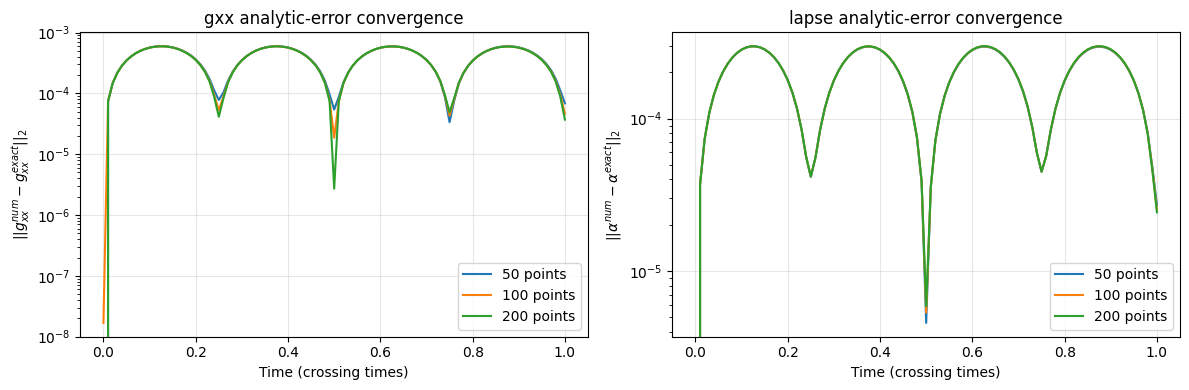

Final-time analytic-error orders:
  gxx  : p(50->100)=0.561, p(100->200)=0.329, fit=0.445
  alpha: p(50->100)=0.106, p(100->200)=0.056, fit=0.081


In [20]:
def fitted_order_from_errors(dxs_in, errs_in):
    x = jnp.log(jnp.asarray(dxs_in))
    y = jnp.log(jnp.asarray(errs_in) + 1e-300)
    x_bar = jnp.mean(x)
    y_bar = jnp.mean(y)
    slope = jnp.sum((x - x_bar) * (y - y_bar)) / jnp.sum((x - x_bar) ** 2)
    return float(slope)


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

final_gxx_errors = []
final_alpha_errors = []

for nx, dx in zip(nxs, dxs):
    gxx_err_hist = all_gxx[nx] - all_gxx_analytic[nx]
    alpha_err_hist = all_alpha[nx] - all_alpha_analytic[nx]

    gxx_err_l2 = l2_norm_over_x(gxx_err_hist, dx)
    alpha_err_l2 = l2_norm_over_x(alpha_err_hist, dx)

    final_gxx_errors.append(gxx_err_l2[-1])
    final_alpha_errors.append(alpha_err_l2[-1])

    axes[0].plot(all_times[nx], gxx_err_l2, label=f'{nx} points')
    axes[1].plot(all_times[nx], alpha_err_l2, label=f'{nx} points')

axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].set_xlabel('Time (crossing times)')
axes[1].set_xlabel('Time (crossing times)')
axes[0].set_ylabel(r'$||g_{xx}^{num} - g_{xx}^{exact}||_2$')
axes[1].set_ylabel(r'$||\alpha^{num} - \alpha^{exact}||_2$')
axes[0].set_title('gxx analytic-error convergence')
axes[1].set_title('lapse analytic-error convergence')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

# Pairwise and fitted orders from final-time analytic errors.
order_gxx_50_100 = float(jnp.log2(final_gxx_errors[0] / final_gxx_errors[1]))
order_gxx_100_200 = float(jnp.log2(final_gxx_errors[1] / final_gxx_errors[2]))
order_alpha_50_100 = float(jnp.log2(final_alpha_errors[0] / final_alpha_errors[1]))
order_alpha_100_200 = float(jnp.log2(final_alpha_errors[1] / final_alpha_errors[2]))

fitted_order_gxx = fitted_order_from_errors(dxs, final_gxx_errors)
fitted_order_alpha = fitted_order_from_errors(dxs, final_alpha_errors)

print('Final-time analytic-error orders:')
print(f'  gxx  : p(50->100)={order_gxx_50_100:.3f}, p(100->200)={order_gxx_100_200:.3f}, fit={fitted_order_gxx:.3f}')
print(f'  alpha: p(50->100)={order_alpha_50_100:.3f}, p(100->200)={order_alpha_100_200:.3f}, fit={fitted_order_alpha:.3f}')


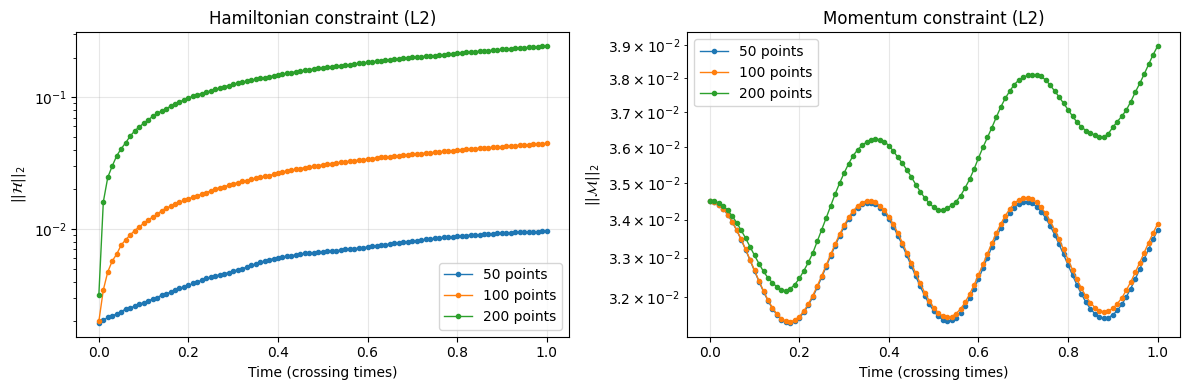

In [21]:
# Constraint diagnostics vs time for each resolution
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for nx in nxs:
    t = all_times[nx]
    ham_hist = all_hamiltonian_constraints[nx]
    mom_hist = all_momentum_constraints[nx]

    ham_l2 = jnp.sqrt(jnp.mean(ham_hist.reshape((ham_hist.shape[0], -1))**2, axis=1))
    mom_l2 = jnp.sqrt(jnp.mean(mom_hist.reshape((mom_hist.shape[0], -1))**2, axis=1))

    axes[0].plot(t, ham_l2, marker='.', linewidth=1, label=f'{nx} points')
    axes[1].plot(t, mom_l2, marker='.', linewidth=1, label=f'{nx} points')

axes[0].set_yscale('log')
axes[1].set_yscale('log')

axes[0].set_xlabel('Time (crossing times)')
axes[0].set_ylabel(r'$||\mathcal{H}||_2$')
axes[0].set_title('Hamiltonian constraint (L2)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('Time (crossing times)')
axes[1].set_ylabel(r'$||\mathcal{M}||_2$')
axes[1].set_title('Momentum constraint (L2)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [22]:
print('First 5 non-trivial CF values for gxx  :', cf_gxx[1:6])
print('First 5 non-trivial CF values for alpha:', cf_alpha[1:6])
print('First 5 observed orders for gxx  :', p_gxx[1:6])
print('First 5 observed orders for alpha:', p_alpha[1:6])
print(f'Initial mean self-convergence order (gxx)  : {initial_order_gxx:.3f}')
print(f'Initial mean self-convergence order (alpha): {initial_order_alpha:.3f}')


First 5 non-trivial CF values for gxx  : [3.976317  3.893255  3.788804  3.641758  3.4901464]
First 5 non-trivial CF values for alpha: [3.9973636 3.9944918 3.9969492 3.994255  4.009902 ]
First 5 observed orders for gxx  : [1.9914327 1.9609767 1.9217426 1.864635  1.8032876]
First 5 observed orders for alpha: [1.9990487 1.9980121 1.9988993 1.9979264 2.003567 ]
Initial mean self-convergence order (gxx)  : 1.908
Initial mean self-convergence order (alpha): 1.999
